In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
titanic = sns.load_dataset('titanic')
titanic['survival_status'] = titanic['survived'].map({0: 'No', 1: 'Yes'})

In [3]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,survival_status
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,No
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,Yes
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,Yes
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,Yes
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,No


In [4]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   survived         891 non-null    int64   
 1   pclass           891 non-null    int64   
 2   sex              891 non-null    object  
 3   age              714 non-null    float64 
 4   sibsp            891 non-null    int64   
 5   parch            891 non-null    int64   
 6   fare             891 non-null    float64 
 7   embarked         889 non-null    object  
 8   class            891 non-null    category
 9   who              891 non-null    object  
 10  adult_male       891 non-null    bool    
 11  deck             203 non-null    category
 12  embark_town      889 non-null    object  
 13  alive            891 non-null    object  
 14  alone            891 non-null    bool    
 15  survival_status  891 non-null    object  
dtypes: bool(2), category(2), float64(2), int64(4

In [5]:
titanic.drop('deck', axis=1, inplace=True)

median_age = titanic['age'].median()
titanic['age'].fillna(median_age, inplace=True)

mode_embarked = titanic['embarked'].mode()[0]
titanic['embarked'].fillna(mode_embarked, inplace=True)

mode_embark_town = titanic['embark_town'].mode()[0]
titanic['embark_town'].fillna(mode_embark_town, inplace=True)


/tmp/ipython-input-826454362.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic['age'].fillna(median_age, inplace=True)
/tmp/ipython-input-826454362.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using

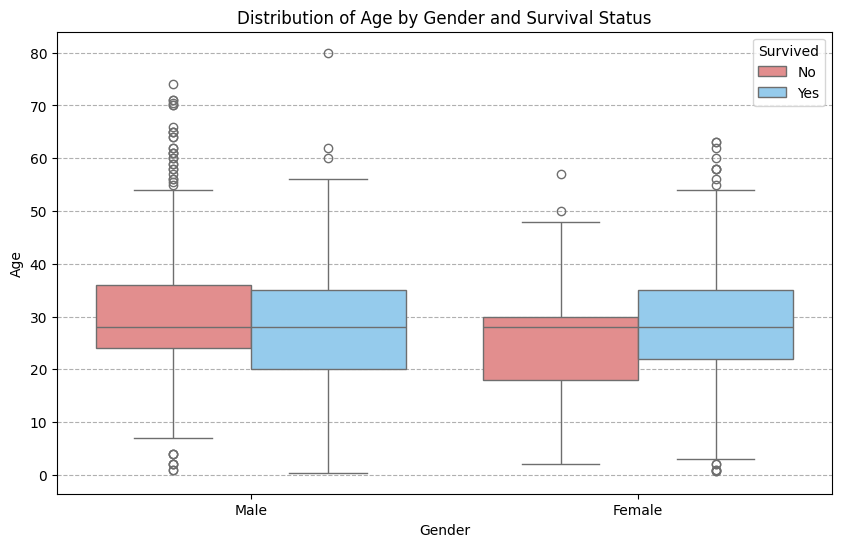

In [6]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=titanic, x='sex', y='age', hue='survival_status', palette={'No': 'lightcoral', 'Yes': 'lightskyblue'})
plt.title('Distribution of Age by Gender and Survival Status')
plt.xlabel('Gender')
plt.ylabel('Age')
plt.xticks(ticks=[0, 1], labels=['Male', 'Female'])
plt.legend(title='Survived')
plt.grid(axis='y', linestyle='--', alpha=1)
plt.show()

# **Summary:**

1.Females show a higher survival rate across a broader age range as compared to males.

2.Also being younger correlated with a higher chance of survival.

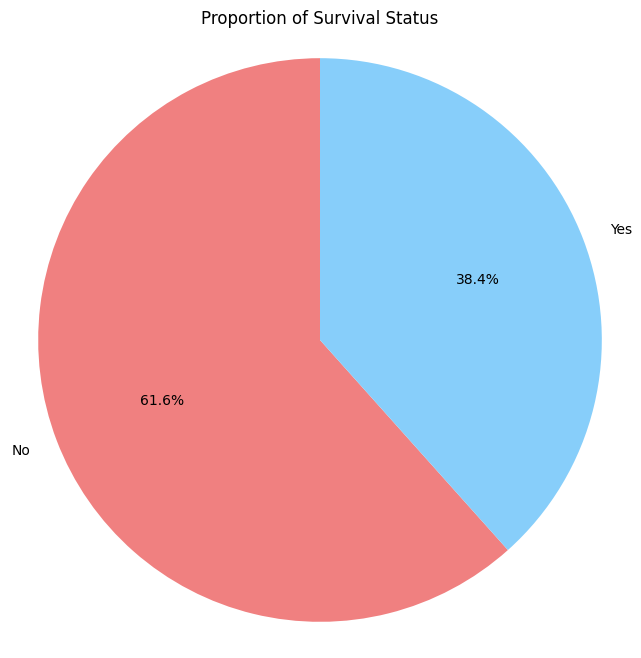

In [7]:
survival_counts = titanic['survival_status'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(survival_counts, labels=survival_counts.index, autopct='%1.1f%%', startangle=90, colors=['lightcoral', 'lightskyblue'])
plt.title('Proportion of Survival Status')
plt.axis('equal')
plt.show()

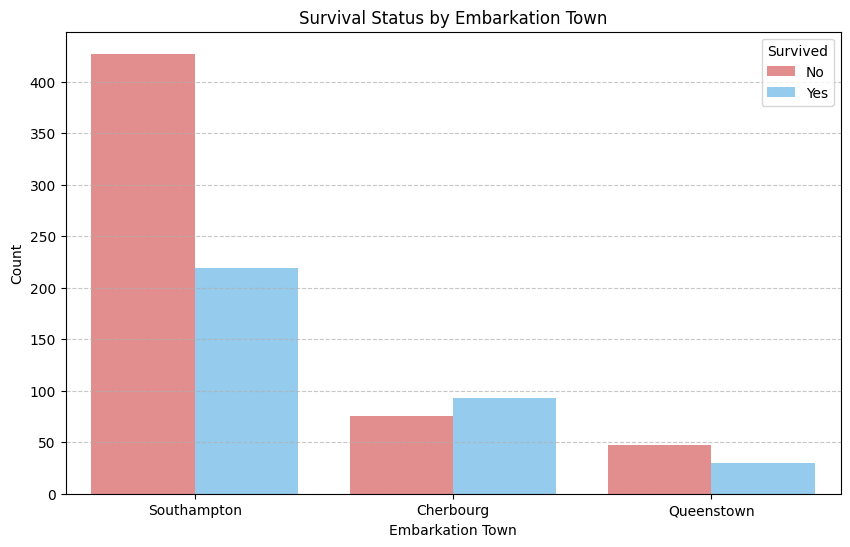

In [8]:
plt.figure(figsize=(10, 6))
sns.countplot(data=titanic, x='embark_town', hue='survival_status', palette={'No': 'lightcoral', 'Yes': 'lightskyblue'})
plt.title('Survival Status by Embarkation Town')
plt.xlabel('Embarkation Town')
plt.ylabel('Count')
plt.legend(title='Survived')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

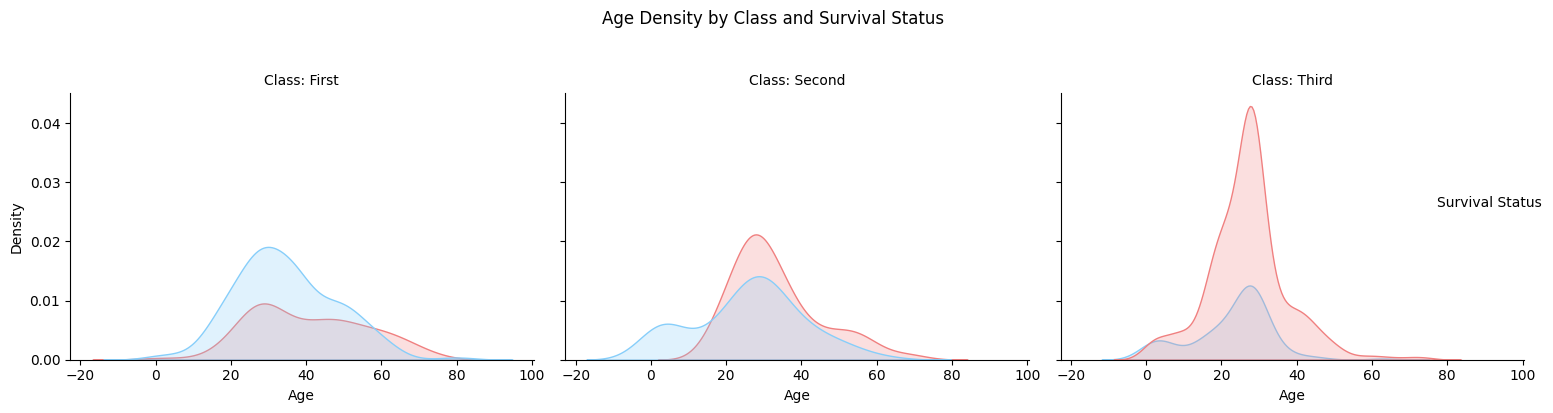

In [10]:
g = sns.FacetGrid(titanic, col='class', col_wrap=3, height=4, aspect=1.2)
g.map_dataframe(sns.kdeplot, x='age', hue='survival_status', fill=True, palette={'No': 'lightcoral', 'Yes': 'lightskyblue'})
g.add_legend(title='Survival Status')
g.set_titles("Class: {col_name}")
g.set_axis_labels('Age', 'Density')
plt.suptitle('Age  by Class and Survival Status', y=1.02) # Adjust suptitle position
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

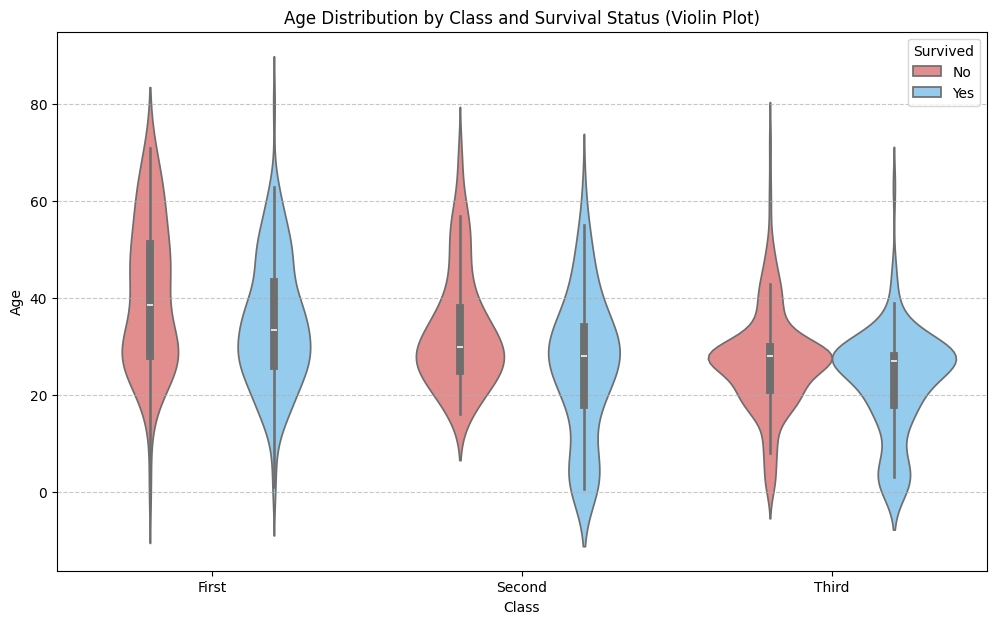

In [11]:
plt.figure(figsize=(12, 7))
sns.violinplot(data=titanic, x='class', y='age', hue='survival_status', palette={'No': 'lightcoral', 'Yes': 'lightskyblue'})
plt.title('Age Distribution by Class and Survival Status (Violin Plot)')
plt.xlabel('Class')
plt.ylabel('Age')
plt.legend(title='Survived')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

The violin plot above visualizes the distribution of 'age' for each passenger class, further broken down by 'survival_status'. The wider sections of the violin indicate a higher density of passengers at that age, providing insights similar to a KDE plot but grouped by class, and showing summary statistics like quartiles (implied by the inner box/marker).

### Inferences from Age Density by Class and Survival Status (KDE Plot)

1.  **First Class (P-class 1):**
    *   There's a noticeable peak of survivors (lightskyblue) around 30-50 years old, indicating that a significant portion of first-class passengers in this age range survived.
    *   Non-survivors (lightcoral) are also present across various ages, but the survival curve often rises above the non-survival curve, particularly for adults.
    *   Children (younger ages) in first class show a very high survival density, suggesting a high survival rate for this group.

2.  **Second Class (P-class 2):**
    *   Survival rates in second class appear to be more balanced between survivors and non-survivors across most age groups compared to first class.
    *   There's a smaller peak of survivors among younger children.
    *   For adult ages, the densities of survivors and non-survivors are often quite close, or non-survivors might even slightly outnumber survivors at certain age ranges.

3.  **Third Class (P-class 3):**
    *   Third class generally shows a significantly higher density of non-survivors across almost all age ranges, especially for adult males.
    *   There's a prominent peak of non-survivors in the young adult to middle-aged range.
    *   While children in third class show some survival, their survival density is much lower compared to children in first and second class, and often overshadowed by non-survivors in the same age group.

### General Observations:
*   **Impact of Class:** Survival chances appear to be strongly correlated with passenger class, with first-class passengers generally having higher survival densities across ages, followed by second, and then third class.
*   **Age and Survival:** There's a visible trend of higher survival density for very young children (infants) across all classes, although the magnitude differs by class. For adults, age also plays a role, with specific peaks for survivors and non-survivors varying by class.
*   **Density vs. Count:** The KDE plot shows the density, providing insights into the distribution and concentration of ages within each group, rather than raw counts.

The KDE plot above visualizes the age distribution for each passenger class, differentiated by survival status. The `fill=True` option shades the area under the density curves, making it easier to see the concentration of ages.

# Task
Analyze the 'Survival Status by Embarkation Town' plot to identify relationships or trends between embarkation town and survival rates, distinguishing between those who survived and those who did not, and provide a summary of these inferences, highlighting key observations about survival rates across different embarkation towns.

## Infer from Embarkation Town Plot

### Subtask:
Analyze the 'Survival Status by Embarkation Town' plot to identify any relationships or trends between the town of embarkation and survival rates, distinguishing between those who survived and those who did not.


### Analysis of Survival Status by Embarkation Town Plot

1.  **Southampton (S):** This town has the highest number of passengers overall. The number of non-survivors (lightcoral) significantly outweighs the number of survivors (lightskyblue).
2.  **Cherbourg (C):** Cherbourg shows a more balanced, and possibly even higher, proportion of survivors (lightskyblue) compared to non-survivors (lightcoral) when considering its total passenger count. This suggests a relatively higher survival rate for passengers embarking from Cherbourg.
3.  **Queenstown (Q):** Queenstown has the fewest passengers. While there are fewer total passengers, the number of non-survivors (lightcoral) still appears to be slightly higher than survivors (lightskyblue), although the difference is not as stark as in Southampton.

## Final Task

### Subtask:
Provide a summary of the inferences drawn from the embarkation town plot, highlighting key observations about survival rates across different embarkation towns.


## Summary:

### Q&A
The analysis of the 'Survival Status by Embarkation Town' plot revealed distinct patterns in survival rates across different embarkation towns. Passengers embarking from Cherbourg (C) appeared to have a relatively higher survival rate compared to those from Southampton (S) and Queenstown (Q).

### Data Analysis Key Findings
*   **Southampton (S):** This town had the highest number of passengers, and the number of non-survivors significantly outweighed the number of survivors.
*   **Cherbourg (C):** Passengers from Cherbourg showed a more balanced, and potentially higher, proportion of survivors compared to non-survivors, indicating a relatively better survival rate for this group.
*   **Queenstown (Q):** This town had the fewest passengers. While the total numbers were small, the number of non-survivors appeared to be slightly higher than survivors, though the disparity was less pronounced than in Southampton.

### Insights or Next Steps
*   The embarkation town of Cherbourg stands out for its comparatively higher survival rate, suggesting that factors associated with passengers from this port (e.g., socioeconomic status, class distribution) might have influenced their survival chances.
*   Further investigation could explore the demographic composition (e.g., passenger class, age, gender) of passengers from each embarkation town to understand the underlying reasons for the observed differences in survival rates.
